# XResNet1d-101 on PTB-XL

Multi-label ECG classification using a 1-D XResNet-101.

## Sections
1. Setup & Data Loading
2. Model Construction
3. Training
4. Evaluation


## 0. Install dependencies

In [1]:
import sys, os
# Add project root to path so local packages are importable
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import sys
print(sys.executable)


c:\Users\inaki\anaconda3\envs\ptbxl\python.exe


## 1. Load PTB-XL data

In [2]:
import sys
from pathlib import Path
sys.path.append(r"C:/Users/inaki/Desktop/TFG/Code/ptbxl_project")

from utils import load_ptbxl, build_dataloaders

# SET DATASET PATH HERE
# By default, it looks for the folder in the directory above the notebook
PATH = Path("../ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/")

# Check if the path exists; if not, print a helpful message
if not PATH.exists():
    print(f"ERROR: Dataset not found at {PATH.absolute()}")
    print("Please update the 'PATH' variable at the top of this notebook.")

SAMPLING_RATE = 100

X_train, X_val, X_test, y_train, y_val, y_test, classes = load_ptbxl(PATH, SAMPLING_RATE)

print("Classes         :", classes)
print("X_train shape   :", X_train.shape)
print("X_val   shape   :", X_val.shape)
print("X_test  shape   :", X_test.shape)


Classes         : ['CD', 'HYP', 'MI', 'NORM', 'STTC']
X_train shape   : (17418, 1000, 12)
X_val   shape   : (2183, 1000, 12)
X_test  shape   : (2198, 1000, 12)


In [3]:
train_dl, val_dl, test_dl = build_dataloaders(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    batch_size=32,
)
print("Dataloaders ready.")


Dataloaders ready.


## 2. Build the XResNet1d-101 model

In [4]:
import torch
from models import build_xresnet1d101

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

model = build_xresnet1d101(
    num_classes=len(classes),
    input_channels=12,
    device=DEVICE,
)
print(model)


Device: cuda
XResNet1d(
  (0): ConvLayer(
    (0): Conv1d(12, 32, kernel_size=(5,), stride=(2,), padding=(2,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (1): ConvLayer(
    (0): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (2): ConvLayer(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): ResBlock(
      (convs): Sequential(
        (0): ConvLayer(
          (0): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
          (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2)

## 3. Train

Epoch   1: train=0.3448  val=0.3176
Epoch   2: train=0.2983  val=0.3126
Epoch   3: train=0.2840  val=0.3443
Epoch   4: train=0.2737  val=0.3003
Epoch   5: train=0.2665  val=0.2870
Epoch   6: train=0.2617  val=0.2980
Epoch   7: train=0.2553  val=0.3245
Epoch   8: train=0.2505  val=0.2881
Epoch   9: train=0.2333  val=0.2874
Epoch  10: train=0.2290  val=0.2896
Early stopping triggered.


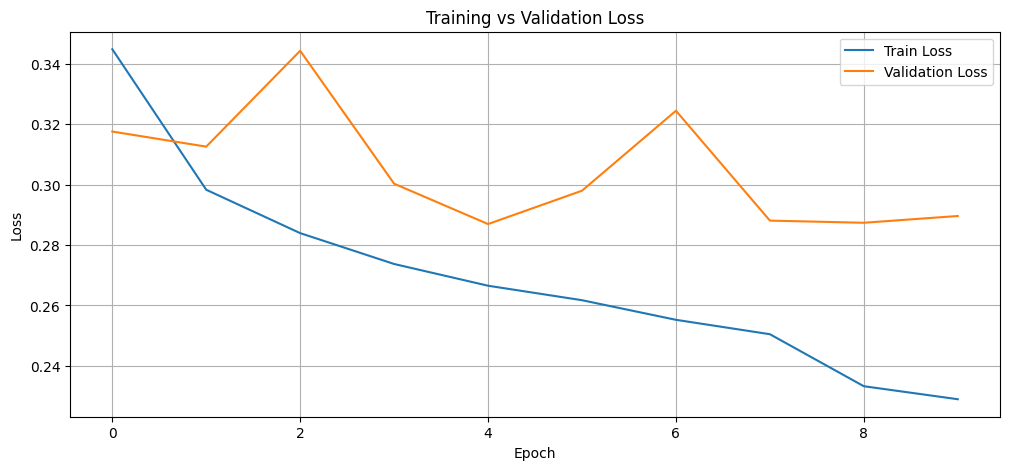

In [5]:
import torch.nn as nn
import torch.optim as optim
from utils import train, plot_losses

import os
os.makedirs("../outputs", exist_ok=True)

# Step 4: Define loss + optimizer
criterion = nn.BCEWithLogitsLoss()      # Since PTB‑XL is multi-label --> BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_losses, val_losses = train(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=50,
    patience=5,
    checkpoint_path="../outputs/best_ecg_model.pt",
    device=DEVICE,
)


plot_losses(train_losses, val_losses, save_path="../outputs/loss_curve.png")


## 4. Evaluation

In [6]:
from utils import (
    get_predictions,
    compute_auc_per_class,
    compute_macro_auc,
    plot_auc_bar,
    plot_prediction_vs_truth,
    plot_confusion_matrices,
    compute_all_metrics,
)

# Load best model
model.load_state_dict(torch.load("../outputs/best_ecg_model.pt", map_location=DEVICE))
model.eval()

all_preds, all_targets = get_predictions(model, test_dl, device=DEVICE)

# -------------------------
# FULL METRICS
# -------------------------
print("\n=== ECG MODEL RESULTS ===")

metrics = compute_all_metrics(all_targets, all_preds)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

C:\Users\inaki\AppData\Local\Temp\ipykernel_22168\3287662731.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../outputs/best_ecg_model


=== ECG MODEL RESULTS ===
Accuracy: 0.6046
F1: 0.6892
Precision (PPV): 0.8024
Sensitivity (Recall): 0.6295
Specificity: 0.9338
MCC: 0.6709
AUC: 0.9167


Per-class AUC: {'CD': 0.9042492703081763, 'HYP': 0.896495094946691, 'MI': 0.9109488084730801, 'NORM': 0.9422940288655981, 'STTC': 0.9296854702380746}
Macro AUC: 0.9167


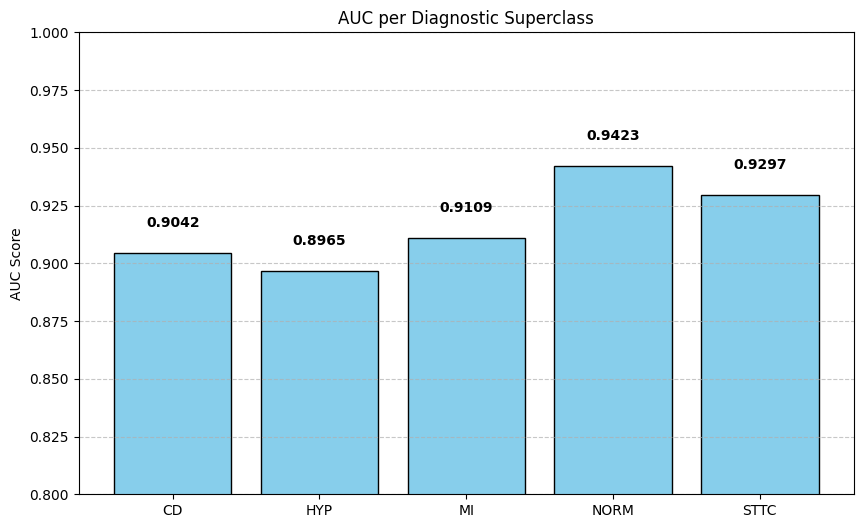

In [7]:
import matplotlib.pyplot as plt

# Per-class & macro AUC
auc_scores = compute_auc_per_class(all_targets, all_preds, classes)
macro_auc  = compute_macro_auc(auc_scores)

print("Per-class AUC:", auc_scores)
print(f"Macro AUC: {macro_auc:.4f}")

# Generate the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(auc_scores.keys(), auc_scores.values(), color='skyblue', edgecolor='black')

# 1. Add text labels on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Zoom the Y-axis to see the differences better (adjust 0.8 to your lowest value)
plt.ylim(0.8, 1.0) 

# 3. Add a title and labels
plt.title('AUC per Diagnostic Superclass')
plt.ylabel('AUC Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("../outputs/auc_bar.png")
plt.show()


Ground truth: [0. 0. 0. 1. 0.]
Predictions : [0.02125143 0.00293188 0.0050657  0.98235506 0.00203647]


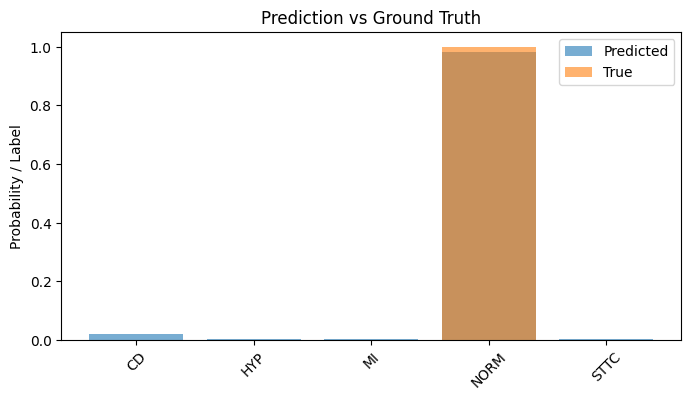

In [8]:
# Single-sample prediction vs truth
plot_prediction_vs_truth(
    all_preds, all_targets, classes,
    sample_idx=0,
    save_path="../outputs/pred_vs_truth.png",
)


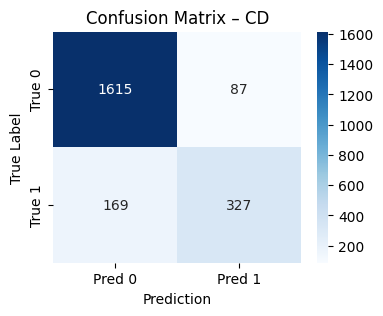

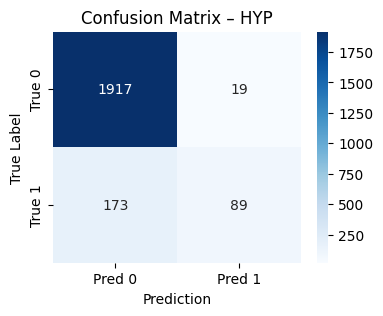

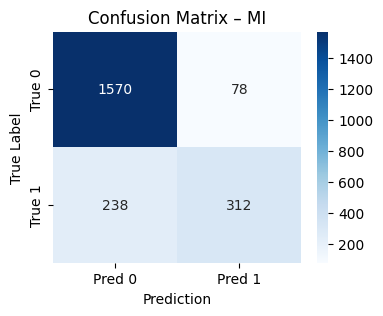

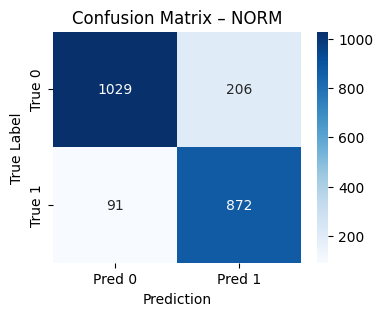

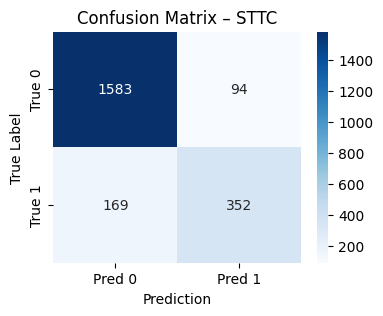

In [9]:
# Confusion matrices for all classes
plot_confusion_matrices(
    all_targets, all_preds, classes,
    threshold=0.5,
    save_dir="../outputs/confusion_matrices",
)
